#### Notebook to make use transects on PNG study areas and plot with lccs category, biomass and height
- load GLO30 (30m product)
- load ESA biomass (100m product) --> resample to 30m as for the transect we want in Mg/ha so it doesnt matter that they will be pixels of same value down from 100m (note: this is a problem for calculating biomass of provinces, but not a problem for transect representations)
- then load LCCS load_reproject(how=dataset.odc.geobox)
- maybe also include this https://glad.umd.edu/dataset/gedi for forest canopy height

In [20]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os, sys
import copy

import numpy as np
import xarray as xr
import geopandas as gpd
import rasterio

import matplotlib
from matplotlib import pyplot
import matplotlib.pyplot as plt

import datacube
from datacube.utils import masking
from datacube.utils.geometry import CRS
from datacube.testutils.io import rio_slurp_xarray
from dea_tools.plotting import display_map
from dea_tools.spatial import xr_rasterize
from datacube.utils.aws import configure_s3_access

# outputs
from datacube.utils.cog import write_cog

from dea_tools.datahandling import load_reproject


dc = datacube.Datacube(app="transects")

# 8.4.25 - Matt Paget work around for error CPLE_HttpResponseError: CURL error: Failed to connect to easi-caching-proxy.caching-proxy port 80 after 0 ms: Couldn't connect to server
sys.path.insert(1, "/home/jovyan/code/easi-notebooks/")
from easi_tools.notebook_utils import unset_cachingproxy

import fiona
import shapely.geometry
from shapely.geometry import shape

from datacube.utils.geometry import Geometry


In [15]:
# Access AWS "requester-pays" buckets
# This is necessary for reading data from most third-party AWS S3 buckets such as for Landsat and Sentinel-2
configure_s3_access(aws_unsigned=False, requester_pays=True);

In [25]:
#transects file will be the file containing our transects
transect_file = './transect_B.gpkg'
transect_df = gpd.read_file(transects_file)
transect_df

,id,geometry
0,1,"MULTILINESTRING ((233248.566 9160189.712, 2324..."


In [36]:
# This defines the function that converts a linear vector file into a string of x,y coordinates

def geom_query(geom, geom_crs='EPSG:32755'):
    """
    Create datacube query snippet for geometry
    """
    return {
        'x': (geom.bounds[0], geom.bounds[2]),
        'y': (geom.bounds[1], geom.bounds[3]),
        'crs': geom_crs
    }

def warp_geometry(geom, crs_crs, dst_crs):
    """
    warp geometry from crs_crs to dst_crs
    """
    return shapely.geometry.shape(rasterio.warp.transform_geom(crs_crs, dst_crs, shapely.geometry.mapping(geom)))

In [37]:
# use fiona module to open the shape file
transect = fiona.open(transect_file)

geom_ = shape(transect[1]['geometry'])
geom_query_ = geom_query(geom=geom_)

crs = "EPSG:32755"
res = (30, -30)

query =({'output_crs':crs,
         'resolution':res})

query.update(geom_query(geom=geom_, geom_crs=transect.crs_wkt))

In [150]:
# load in GLO data 
with unset_cachingproxy():
    GLO30 = dc.load(product='copernicus_dem_30', resampling='bilinear', time = ('2022-01-01', '2022-12-31'), **query)

In [151]:
# load ESA biomass
with unset_cachingproxy():
    ESAbiomass = dc.load(product='cci_biomass_annual_v51', measurements = 'agb', resampling='bilinear', time = ('2020-01-01', '2020-12-31'), **query)

In [152]:
# load LCCS band 5 for BCEs
# LCCS data EPSG:32755 30m pixel
LCCS_path = '/home/jovyan/code/livingearth_png/notebooks/png_lccs_classification_v0_2_data_merged.tif'
LCCS_load = load_reproject(path=LCCS_path, how=GLO30.odc.geobox).load()
LCCS_load = LCCS_load.rename('lccs')

In [153]:
# Compress 
crs_wkt = GLO30.crs
geom_w = warp_geometry(geom_, query['crs'], crs_wkt)

In [154]:
dist = [i for i in range(0, int(geom_w.length), 30)]

points = list(zip(*[geom_w.interpolate(d).coords[0] for d in dist])) # py3

In [155]:
GLO30_sel = GLO30.sel(x=xr.DataArray(x_dim, dims='distance'),
                        y=xr.DataArray(y_dim, dims='distance'),
                        method='nearest')

ESAbiomass_sel = ESAbiomass.sel(x=xr.DataArray(x_dim, dims='distance'),
                        y=xr.DataArray(y_dim, dims='distance'),
                        method='nearest')

LCCS_load_sel = LCCS_load.sel(x=xr.DataArray(x_dim, dims='distance'),
                        y=xr.DataArray(y_dim, dims='distance'),
                        method='nearest')

In [249]:
GLO30_data = GLO30_sel.elevation.squeeze('time')
GLO30_data_df = GLO30_data.to_dataframe().reset_index()
GLO30_data_df_pivoted = GLO30_data_df.pivot(index='time', columns='distance', values='elevation')
GLO30_data_df_pivoted.columns = (GLO30_data_df_pivoted.columns.astype(int) * 0.03).astype(str)

ESAbiomass_data = ESAbiomass_sel.agb.squeeze('time')
ESAbiomass_data_df = ESAbiomass_data.to_dataframe().reset_index()
ESAbiomass_data_df_pivoted = ESAbiomass_data_df.pivot(index='time', columns='distance', values='agb')
ESAbiomass_data_df_pivoted.columns = (ESAbiomass_data_df_pivoted.columns.astype(int) * 0.03).astype(str)

LCCS_data = LCCS_load_sel[4]
LCCS_data_df = LCCS_data.to_dataframe().reset_index()
LCCS_data_df_pivoted = LCCS_data_df.pivot(index='band', columns='distance', values='lccs')
LCCS_data_df_pivoted.columns = (LCCS_data_df_pivoted.columns.astype(int) * 0.03).astype(str)


In [250]:
GLO30_data_df_pivoted

distance,0.0,0.03,0.06,0.09,0.12,0.15,0.18,0.21,0.24,0.27,...,37.019999999999996,37.05,37.08,37.11,37.14,37.17,37.199999999999996,37.23,37.26,37.29
time,,,,,,,,,,,,,,,,,,,,,
2022-12-01,23.567101,21.487297,20.935587,21.400299,24.867105,26.510843,25.223204,22.645828,19.075323,20.982397,...,75.373512,78.335579,80.245514,78.473801,77.125877,72.194832,68.275459,65.581932,73.032364,69.78923


In [251]:
import pandas as pd
combined_df = pd.concat([LCCS_data_df_pivoted, GLO30_data_df_pivoted, ESAbiomass_data_df_pivoted], axis=0)

# Rename the index (rows) to df1, df2, df3
combined_df.index = ['LCCS'] * len(LCCS_data_df_pivoted) + ['GLO30m'] * len(GLO30_data_df_pivoted) + ['ESAbiomass'] * len(ESAbiomass_data_df_pivoted)

In [252]:
combined_df

distance,0.0,0.03,0.06,0.09,0.12,0.15,0.18,0.21,0.24,0.27,...,37.019999999999996,37.05,37.08,37.11,37.14,37.17,37.199999999999996,37.23,37.26,37.29
LCCS,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1121.000000,1121.000000,1121.000000,1121.000000,1121.000000,1121.000000,1121.000000,1121.000000,1121.000000,1121.00000
GLO30m,23.567101,21.487297,20.935587,21.400299,24.867105,26.510843,25.223204,22.645828,19.075323,20.982397,...,75.373512,78.335579,80.245514,78.473801,77.125877,72.194832,68.275459,65.581932,73.032364,69.78923
ESAbiomass,165.000000,166.000000,168.000000,170.000000,171.000000,164.000000,156.000000,148.000000,147.000000,150.000000,...,265.000000,284.000000,303.000000,321.000000,338.000000,355.000000,371.000000,360.000000,350.000000,339.00000


In [235]:
# save as csv
# combined_df.to_csv('transect_B.csv',index=False)

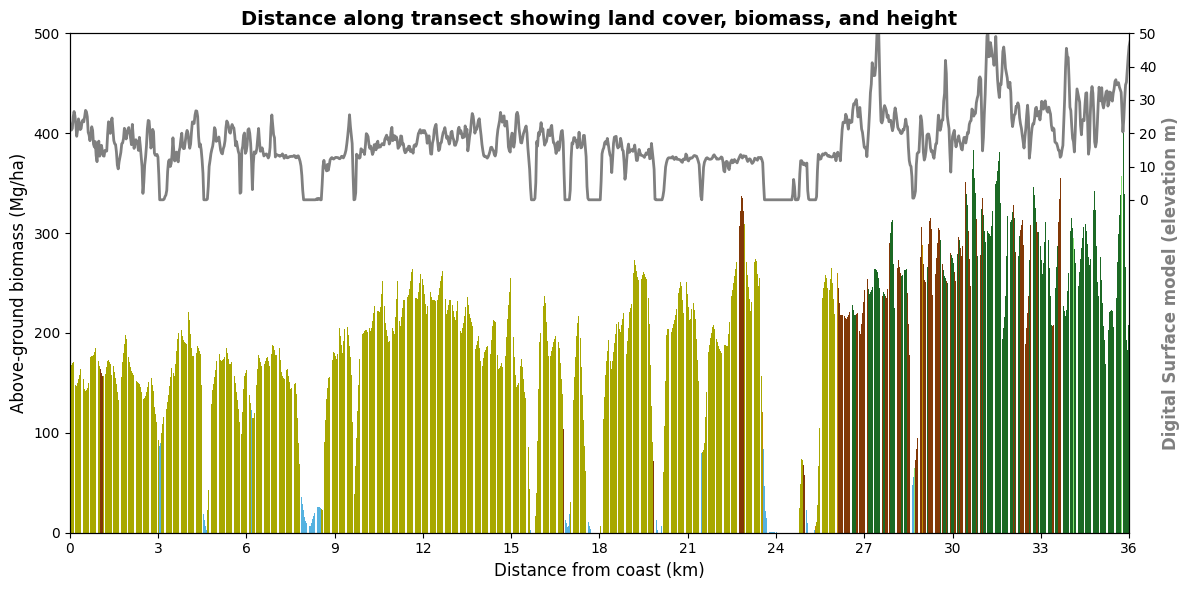

In [254]:
import matplotlib.pyplot as plt
import numpy as np

# Color scheme dictionary
PNG_BCE_COLOUR_SCHEME = {
    1: (168, 168, 0, 255),      # mangrove
    2: (130, 56, 6, 255),       # tidally influenced forests
    3: (191, 142, 1, 255),      # saltmarsh
    1121: (27, 105, 36, 255),   # natural terrestrial woody vegetation
    1122: (136, 230, 115, 255), # natural terrestrial herbaceous vegetation
    1241: (26, 135, 69, 255),   # natural aquatic woody vegetation
    1242: (96, 189, 150, 255),  # natural aquatic herbaceous vegetation
    2000: (177, 169, 186, 255), # unvegetated
    2150: (230, 90, 90, 255),   # artificial surfaces
    2160: (201, 165, 113, 255), # natural bare surfaces
    2200: (85, 178, 224, 255),  # waterbodies
}

# Extract data
distance = combined_df.columns  # Distance columns (assuming distance is the column names)
LCCS = combined_df.loc['LCCS']  # LCCS data
GLO30 = combined_df.loc['GLO30m']  # GLO30 data
ESAbiomass = combined_df.loc['ESAbiomass']  # ESAbiomass data

# Map each LCCS value to a color from the PNG_BCE_COLOUR_SCHEME
bar_colors = [PNG_BCE_COLOUR_SCHEME.get(value, (169, 169, 169, 255)) for value in LCCS]  # Default to grey if no color in dict

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot ESAbiomass as a bar chart (using LCCS values for color from the dictionary)
bars = ax1.bar(distance, ESAbiomass, color=np.array(bar_colors) / 255)  # Normalize RGB values to [0, 1]

# Create a second y-axis to overlay GLO30 as a line
ax2 = ax1.twinx()
ax2.plot(distance, GLO30, color='tab:grey', label='GLO30', linewidth=2, linestyle='-')  # Dashed line

# Labeling the axes with bold font
ax1.set_xlabel('Distance from coast (km)', fontsize=12)
ax1.set_ylabel('Above-ground biomass (Mg/ha)', color='black', fontsize=12)
ax2.set_ylabel('Digital Surface model (elevation m)', color='tab:grey', fontsize=12, fontweight='bold')

# Set the x-axis limits to the minimum and maximum of the data
ax1.set_xlim(min(distance), max(distance))

# Set the y-axis for ESAbiomass from 0 to 500
ax1.set_ylim(0, 500)

# Set the y-axis for GLO30 from 0 to 100
ax2.set_ylim(-100, 50)

# Only show ticks from 0 to 100 (hides negative ticks)
ax2.set_yticks(np.arange(0, 60, 10))  # adjust step as needed

# Set x-axis ticks every 5
ax1.set_xticks(np.arange(0, len(distance), 100))

# Function to modify x-axis tick labels by multiplying by 30 (from pixels to distance (m))
def multiply_by_30(value, pos):
    return int(value * 0.03)

# Apply the custom function to the x-axis tick labels
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(multiply_by_30))

# Adding a title with bold font
ax1.set_title('Distance along transect showing land cover, biomass, and height', fontsize=14, fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()
